# Experiment 3: Scalability and Data Efficiency (RQ3)

This experiment investigates **how the amount of training data affects learning**
for two architectures on the **IMDb Movie Reviews** dataset:

1. **Standalone BERT** — `bert-base-uncased` + a linear head on the `[CLS]` token.
2. **Hybrid BERT + GAT** — BERT token embeddings are placed on a per-document
   **syntactic dependency graph** (the topology selected for Experiment 2) and
   refined by a Graph Attention Network before pooling and classification.

We train both models on increasing fractions of the training split
(**10%, 25%, 50%, 100%**) and always evaluate on the **same full test set**.
For each model and fraction we record **Accuracy**, **Macro-F1**, and the
**convergence rate** (epoch at which the best validation Macro-F1 was reached).
The goal is to test whether the explicit grammatical structure of the GAT acts
as an inductive bias that makes the hybrid model more **data-efficient**.

The data loading, splitting, spaCy tokenisation and dependency-graph
construction below are reused directly from Experiment 1; the BERT encoder,
subword-to-node alignment, and the learning-curve loop are new.

In [ ]:
!pip -q install torch_geometric
!pip -q install datasets spacy scikit-learn pandas tqdm kagglehub transformers
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Imports and setup

In [ ]:
import re
import copy
import random
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.stats import ttest_rel

import spacy
import kagglehub
from transformers import AutoModel, AutoTokenizer

from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.utils import scatter   # PyG >= 2.3

import matplotlib.pyplot as plt

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

nlp = spacy.load("en_core_web_sm", disable=["ner"])
nlp.max_length = 2_000_000

Device: cuda


## 2. Experiment configuration

In [ ]:
# ---- model / encoder ----
BERT_NAME      = "bert-base-uncased"
MAX_TOKENS     = 256      # max spaCy tokens (graph nodes) per document
BERT_MAX_LEN   = 384      # max BERT sub-word length (sub-words expand the token count)
HIDDEN_DIM     = 64
HEADS          = 4
DROPOUT        = 0.3

# ---- data ----
N_PER_CLASS    = 1000     # IMDb samples per class (2000 docs total, as in Experiment 1)
FRACTIONS      = [1.00]   # of the TRAINING split
SUBSET_SEED    = 42       # fixes which documents land in each fraction

# ---- training ----
FINE_TUNE_BERT = True     # fine-tune BERT in both models (fair comparison). Set False to freeze for speed.
BERT_LR        = 2e-5
HEAD_LR        = 1e-3     # GAT layers + classifier (trained from scratch)
WEIGHT_DECAY   = 1e-4
BATCH_SIZE     = 16
MAX_EPOCHS     = 15
PATIENCE       = 3

# Seeds for repeated runs. A single seed gives one clean learning curve;
# add more (e.g. [13, 42, 87]) for error bars at the cost of compute.
SEEDS          = [13, 21, 42]

tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
PAD_ID = tokenizer.pad_token_id
print("Tokenizer loaded. pad_token_id =", PAD_ID)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer loaded. pad_token_id = 0


## 3. Load the IMDb dataset

Identical loader to Experiment 1: balanced binary sentiment classification from
the Kaggle 50k IMDb reviews dump.

In [ ]:
def load_imdb_kaggle(n_per_class=1000, seed=42):
    path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    csv_path = os.path.join(path, "IMDB Dataset.csv")

    df = pd.read_csv(csv_path)
    df["text"] = df["review"].astype(str)
    df = df[df["text"].str.strip().str.len() > 100].copy()

    old_to_new = {"negative": 0, "positive": 1}
    new_to_old = {0: "negative", 1: "positive"}

    df["original_label"] = df["sentiment"]
    df["label"] = df["sentiment"].map(old_to_new)

    df = (
        df.groupby("label", group_keys=False)
          .apply(lambda x: x.sample(min(len(x), n_per_class), random_state=seed))
          .reset_index(drop=True)
    )
    return df, old_to_new, new_to_old


df_imdb, imdb_old_to_new, imdb_new_to_old = load_imdb_kaggle(n_per_class=N_PER_CLASS, seed=42)
num_classes = df_imdb["label"].nunique()

print("IMDb shape:", df_imdb.shape)
print("Classes:", num_classes)
print(df_imdb["original_label"].value_counts())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
IMDb shape: (2000, 5)
Classes: 2
original_label
negative    1000
positive    1000
Name: count, dtype: int64


/tmp/ipykernel_57068/628922819.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_class), random_state=seed))


## 4. Train / validation / test split

Same 70/15/15 stratified split as Experiment 1. The **test and validation sets
are fixed and full-sized**; only the training portion is later sub-sampled.

In [ ]:
def make_splits(df, seed=42, train_size=0.70, val_size=0.15, test_size=0.15):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6

    texts = df["text"].tolist()
    labels = df["label"].astype(int).tolist()

    train_texts, temp_texts, train_y, temp_y = train_test_split(
        texts, labels, train_size=train_size, stratify=labels, random_state=seed
    )
    relative_val_size = val_size / (val_size + test_size)
    val_texts, test_texts, val_y, test_y = train_test_split(
        temp_texts, temp_y, train_size=relative_val_size, stratify=temp_y, random_state=seed
    )
    return train_texts, val_texts, test_texts, train_y, val_y, test_y


train_texts, val_texts, test_texts, train_y, val_y, test_y = make_splits(df_imdb, seed=42)
print("Split sizes  train/val/test:", len(train_texts), len(val_texts), len(test_texts))

Split sizes  train/val/test: 1400 300 300


## 5. spaCy tokenisation and dependency edges

`process_spacy_doc` is extended from Experiment 1 with the **character offsets**
(`idx`, `end`) of every kept token. These offsets are what let us line up each
graph node with the BERT sub-words that fall inside it.

`build_dependency_edges` is reused **unchanged** from Experiment 1 — it only
needs each token's spaCy index `i` and its head index `head_i`.

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def process_spacy_doc(doc, max_tokens=MAX_TOKENS):
    """Keep alpha/content tokens with their spaCy indices, heads, and char spans."""
    token_info = []
    for tok in doc:
        if tok.is_space or tok.is_punct:
            continue
        token_info.append({
            "text": tok.text.lower(),
            "i": tok.i,
            "head_i": tok.head.i,
            "dep": tok.dep_,
            "pos": tok.pos_,
            "is_alpha": tok.is_alpha,
            "idx": tok.idx,                       # start char in the (cleaned) text
            "end": tok.idx + len(tok.text),       # end char (exclusive)
        })
        if len(token_info) >= max_tokens:
            break
    return token_info


def build_dependency_edges(token_info):
    """Bidirectional syntactic-head edges + self-loops (identical to Experiment 1)."""
    num_nodes = len(token_info)
    edges = set()
    if num_nodes == 0:
        return torch.tensor([[0], [0]], dtype=torch.long)

    original_to_node = {tok["i"]: ni for ni, tok in enumerate(token_info)}
    for ni, tok in enumerate(token_info):
        edges.add((ni, ni))
        head_original_i = tok["head_i"]
        if head_original_i in original_to_node:
            head_node_i = original_to_node[head_original_i]
            if head_node_i != ni:
                edges.add((ni, head_node_i))
                edges.add((head_node_i, ni))

    return torch.tensor(list(edges), dtype=torch.long).t().contiguous()

## 6. Subword-to-node alignment and example builder

For each document we:

1. clean the text once and feed the **same string** to spaCy and to the BERT tokenizer,
2. parse it into graph nodes (spaCy tokens) and dependency edges,
3. tokenise it for BERT with `return_offsets_mapping=True`,
4. map every BERT sub-word to the graph node whose character span contains it
   (sub-words of the same word point to the same node; special tokens map to `-1`).

The BERT embeddings themselves are **not** stored here — they are produced inside
the model during training so that BERT can be fine-tuned. Each example only holds
`input_ids`, `attention_mask`, the dependency `edge_index`, and the
`sub_node_local` map.

In [ ]:
def align_subwords_to_nodes(token_info, offsets, text_len):
    """Map each BERT sub-word (by its char offset) to a graph node, or -1."""
    char_to_node = [-1] * text_len
    for n, tok in enumerate(token_info):
        for c in range(tok["idx"], min(tok["end"], text_len)):
            char_to_node[c] = n

    sub_node_local = []
    for (a, b) in offsets:
        if a == b == 0:                 # special token (CLS / SEP / PAD)
            sub_node_local.append(-1)
        elif a < text_len:
            sub_node_local.append(char_to_node[a])
        else:
            sub_node_local.append(-1)
    return sub_node_local


def build_examples(texts, labels, desc="docs"):
    """Return a list of per-document examples ready for the BERT/BERT-GAT models."""
    cleaned = [clean_text(t) for t in texts]
    examples = []

    docs = nlp.pipe(cleaned, batch_size=64)
    for cln, doc, label in tqdm(zip(cleaned, docs, labels), total=len(labels), desc=desc):
        token_info = process_spacy_doc(doc, max_tokens=MAX_TOKENS)

        if len(token_info) == 0:
            # Degenerate doc: one isolated node with a self-loop.
            examples.append({
                "input_ids": [tokenizer.cls_token_id, tokenizer.sep_token_id],
                "attention_mask": [1, 1],
                "sub_node_local": [-1, -1],
                "edge_index": torch.tensor([[0], [0]], dtype=torch.long),
                "num_nodes": 1,
                "y": int(label),
            })
            continue

        edge_index = build_dependency_edges(token_info)

        enc = tokenizer(
            cln,
            truncation=True,
            max_length=BERT_MAX_LEN,
            return_offsets_mapping=True,
        )
        sub_node_local = align_subwords_to_nodes(token_info, enc["offset_mapping"], len(cln))

        examples.append({
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "sub_node_local": sub_node_local,
            "edge_index": edge_index,
            "num_nodes": len(token_info),
            "y": int(label),
        })
    return examples

## 7. Build all examples once

spaCy parsing and tokenisation are done **once** for the full training, validation
and test splits. The data-fraction experiment later just selects subsets of the
pre-built training examples, so no preprocessing is repeated.

In [ ]:
train_examples = build_examples(train_texts, train_y, desc="train")
val_examples   = build_examples(val_texts,   val_y,   desc="val")
test_examples  = build_examples(test_texts,  test_y,  desc="test")

print("Examples built:", len(train_examples), len(val_examples), len(test_examples))
print("Example node counts (first 5 train):", [e["num_nodes"] for e in train_examples[:5]])

train:   0%|          | 0/1400 [00:00<?, ?it/s]

val:   0%|          | 0/300 [00:00<?, ?it/s]

test:   0%|          | 0/300 [00:00<?, ?it/s]

Examples built: 1400 300 300
Example node counts (first 5 train): [124, 196, 256, 206, 127]


## 8. Stratified training subsets

Each fraction is a **stratified** sub-sample of the full training split, drawn with
a fixed `SUBSET_SEED` so the same documents are used across model seeds (only model
initialisation and training stochasticity vary).

In [ ]:
def make_fraction_indices(labels, fraction, seed=SUBSET_SEED):
    n = len(labels)
    if fraction >= 1.0:
        return list(range(n))
    idx = np.arange(n)
    sub_idx, _ = train_test_split(
        idx, train_size=fraction, stratify=labels, random_state=seed
    )
    return sub_idx.tolist()


fraction_indices = {f: make_fraction_indices(train_y, f) for f in FRACTIONS}
for f in FRACTIONS:
    print(f"Fraction {int(f*100):3d}%  ->  {len(fraction_indices[f])} training documents")

Fraction 100%  ->  1400 training documents


## 9. Batching

A single custom `collate_fn` produces a batch usable by **both** models:

* the standalone BERT model uses only `input_ids`, `attention_mask`, `y`;
* the hybrid model additionally uses the batched `edge_index`, the `batch_vec`
  (node → graph id for pooling) and the `(sub_flat, node_flat)` index pair that
  scatters BERT sub-word outputs onto graph nodes.

All per-document dependency graphs are merged into one big disconnected graph by
offsetting node indices, exactly as PyG does internally.

In [ ]:
class GraphBatch:
    def __init__(self, **kw):
        self.__dict__.update(kw)

    def to(self, device):
        for k, v in self.__dict__.items():
            if torch.is_tensor(v):
                setattr(self, k, v.to(device))
        return self


def collate_fn(examples):
    B = len(examples)
    Lmax = max(len(e["input_ids"]) for e in examples)

    input_ids = torch.full((B, Lmax), PAD_ID, dtype=torch.long)
    attention_mask = torch.zeros((B, Lmax), dtype=torch.long)
    y = torch.tensor([e["y"] for e in examples], dtype=torch.long)

    edge_list, batch_vec = [], []
    sub_flat, node_flat = [], []
    node_offset = 0

    for i, e in enumerate(examples):
        L = len(e["input_ids"])
        input_ids[i, :L] = torch.tensor(e["input_ids"], dtype=torch.long)
        attention_mask[i, :L] = torch.tensor(e["attention_mask"], dtype=torch.long)

        N = e["num_nodes"]
        edge_list.append(e["edge_index"] + node_offset)
        batch_vec.append(torch.full((N,), i, dtype=torch.long))

        for p, n in enumerate(e["sub_node_local"]):
            if n >= 0:
                sub_flat.append(i * Lmax + p)     # index into flattened [B*Lmax]
                node_flat.append(node_offset + n)
        node_offset += N

    edge_index = torch.cat(edge_list, dim=1) if edge_list else torch.zeros((2, 0), dtype=torch.long)
    batch_vec = torch.cat(batch_vec)
    sub_flat = torch.tensor(sub_flat, dtype=torch.long)
    node_flat = torch.tensor(node_flat, dtype=torch.long)

    return GraphBatch(
        input_ids=input_ids,
        attention_mask=attention_mask,
        y=y,
        edge_index=edge_index,
        batch_vec=batch_vec,
        sub_flat=sub_flat,
        node_flat=node_flat,
        total_nodes=node_offset,
    )


def make_loader(examples, indices=None, shuffle=False):
    data = examples if indices is None else [examples[i] for i in indices]
    return DataLoader(data, batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=collate_fn)

## 10. Models

**Standalone BERT** classifies on the `[CLS]` representation. **Hybrid BERT-GAT**
scatter-means BERT sub-word outputs onto graph nodes, runs the same two-layer GAT
used in Experiment 1 (4 heads then 1 head), mean-pools the nodes, and classifies.

In [ ]:
class BertClassifier(nn.Module):
    def __init__(self, num_classes, dropout=DROPOUT):
        super().__init__()
        self.bert = AutoModel.from_pretrained(BERT_NAME)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, batch):
        out = self.bert(input_ids=batch.input_ids, attention_mask=batch.attention_mask)
        cls = out.last_hidden_state[:, 0]          # [CLS] token
        return self.classifier(self.dropout(cls))


class BertGAT(nn.Module):
    def __init__(self, num_classes, hidden_dim=HIDDEN_DIM, heads=HEADS, dropout=DROPOUT):
        super().__init__()
        self.bert = AutoModel.from_pretrained(BERT_NAME)
        h = self.bert.config.hidden_size           # 768

        self.gat1 = GATConv(h, hidden_dim, heads=heads, concat=True,
                            dropout=dropout, add_self_loops=False)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=False,
                            dropout=dropout, add_self_loops=False)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, batch):
        out = self.bert(input_ids=batch.input_ids, attention_mask=batch.attention_mask)
        H = out.last_hidden_state                  # [B, L, 768]
        B, L, Hdim = H.shape

        # Pool BERT sub-words onto graph nodes (mean over sub-words of each token).
        Hflat = H.reshape(B * L, Hdim)
        gathered = Hflat[batch.sub_flat]           # [num_aligned_subwords, 768]
        x = scatter(gathered, batch.node_flat, dim=0,
                    dim_size=batch.total_nodes, reduce="mean")   # [total_nodes, 768]

        x = self.gat1(x, batch.edge_index); x = F.elu(x); x = self.dropout(x)
        x = self.gat2(x, batch.edge_index); x = F.elu(x)

        graph_emb = global_mean_pool(x, batch.batch_vec)
        return self.classifier(self.dropout(graph_emb))

## 11. Optimiser, training and evaluation

BERT parameters use a small learning rate (`2e-5`); the randomly-initialised GAT
and classifier heads use a larger one (`1e-3`). Setting `FINE_TUNE_BERT=False`
freezes BERT and trains only the heads (much faster, useful for a quick run).

In [ ]:
def make_optimizer(model):
    bert_params, head_params = [], []
    for name, p in model.named_parameters():
        if name.startswith("bert."):
            if FINE_TUNE_BERT:
                bert_params.append(p)
            else:
                p.requires_grad = False
        else:
            head_params.append(p)

    groups = [{"params": head_params, "lr": HEAD_LR}]
    if FINE_TUNE_BERT:
        groups.append({"params": bert_params, "lr": BERT_LR})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        loss = F.cross_entropy(logits, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.y.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_full(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        preds = model(batch).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return acc, macro_f1, all_preds, all_labels

In [ ]:
def train_model(model_class, train_loader, val_loader, test_loader, seed):
    """Train one model with early stopping; return test metrics + epoch-to-best."""
    set_seed(seed)
    model = model_class(num_classes=num_classes).to(device)
    optimizer = make_optimizer(model)

    best_val_f1 = -1.0
    best_epoch = 0
    patience_counter = 0
    best_state = None

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_acc, val_f1, _, _ = evaluate_full(model, val_loader)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_acc, test_f1, preds, labels = evaluate_full(model, test_loader)
    return {
        "test_acc": test_acc,
        "test_f1": test_f1,
        "best_epoch": best_epoch,      # convergence rate: epochs to optimal val F1
        "preds": preds,
        "labels": labels,
    }

## 12. Learning-curve loop

For every fraction we train both models across all seeds and store the
mean ± std of accuracy, Macro-F1, and epochs-to-best. The validation and test
loaders are built once and reused for every fraction.

In [ ]:
val_loader  = make_loader(val_examples,  shuffle=False)
test_loader = make_loader(test_examples, shuffle=False)

MODELS = {"BERT": BertClassifier, "BERT+GAT": BertGAT}

results = {name: {"acc": {}, "f1": {}, "epoch": {},
                  "acc_runs": {}, "f1_runs": {}, "last": {}}
           for name in MODELS}

for f in FRACTIONS:
    idx = fraction_indices[f]
    train_loader = make_loader(train_examples, indices=idx, shuffle=True)
    print(f"\n================  Fraction {int(f*100)}%  ({len(idx)} docs)  ================")

    for name, model_class in MODELS.items():
        accs, f1s, epochs = [], [], []
        last_run = None
        for seed in SEEDS:
            run = train_model(model_class, train_loader, val_loader, test_loader, seed)
            accs.append(run["test_acc"])
            f1s.append(run["test_f1"])
            epochs.append(run["best_epoch"])
            last_run = run
            print(f"  [{name:8s} seed={seed:>3}]  "
                  f"acc={run['test_acc']*100:5.2f}  f1={run['test_f1']*100:5.2f}  "
                  f"best_epoch={run['best_epoch']}")

        results[name]["acc"][f]      = (np.mean(accs) * 100, np.std(accs, ddof=1) * 100 if len(accs) > 1 else 0.0)
        results[name]["f1"][f]       = (np.mean(f1s)  * 100, np.std(f1s,  ddof=1) * 100 if len(f1s)  > 1 else 0.0)
        results[name]["epoch"][f]    = (np.mean(epochs), np.std(epochs, ddof=1) if len(epochs) > 1 else 0.0)
        results[name]["acc_runs"][f] = accs
        results[name]["f1_runs"][f]  = f1s
        results[name]["last"][f]     = last_run

print("\nDone.")


================  Fraction 100%  (1400 docs)  ================


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [BERT     seed= 13]  acc=89.00  f1=88.99  best_epoch=3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [BERT+GAT seed= 21]  acc=87.67  f1=87.64  best_epoch=3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [BERT+GAT seed= 42]  acc=86.33  f1=86.33  best_epoch=6

Done.


## 13. Results table

In [ ]:
rows = []
for f in FRACTIONS:
    for name in MODELS:
        acc_m, acc_s = results[name]["acc"][f]
        f1_m, f1_s   = results[name]["f1"][f]
        ep_m, ep_s   = results[name]["epoch"][f]
        rows.append({
            "Fraction": f"{int(f*100)}%",
            "Train docs": len(fraction_indices[f]),
            "Model": name,
            "Accuracy (%)": f"{acc_m:.2f} ± {acc_s:.2f}",
            "Macro-F1 (%)": f"{f1_m:.2f} ± {f1_s:.2f}",
            "Epochs to best": f"{ep_m:.1f}" + (f" ± {ep_s:.1f}" if ep_s else ""),
        })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
results_df

Fraction  Train docs    Model Accuracy (%) Macro-F1 (%) Epochs to best
    100%        1400     BERT 88.78 ± 1.68 88.77 ± 1.68      2.0 ± 1.0
    100%        1400 BERT+GAT 88.22 ± 2.22 88.21 ± 2.22      3.3 ± 2.5


,Fraction,Train docs,Model,Accuracy (%),Macro-F1 (%),Epochs to best
0,100%,1400,BERT,88.78 ± 1.68,88.77 ± 1.68,2.0 ± 1.0
1,100%,1400,BERT+GAT,88.22 ± 2.22,88.21 ± 2.22,3.3 ± 2.5


## 14. Learning-curve plots

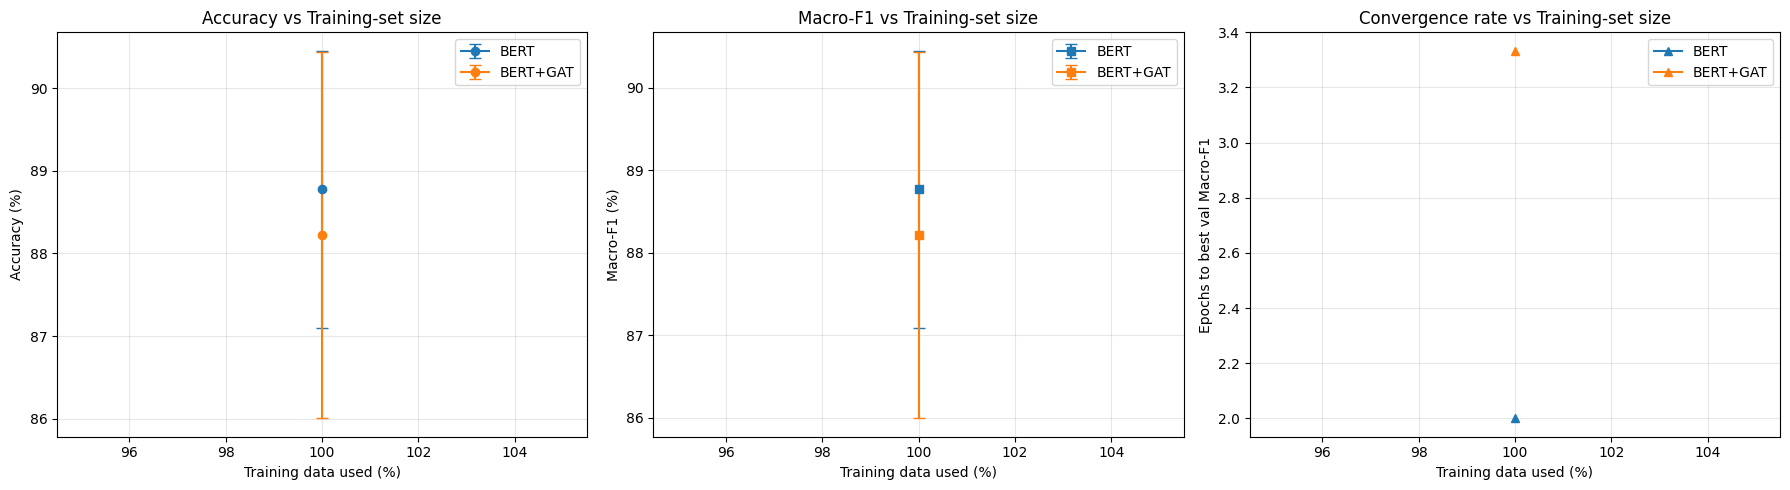

In [ ]:
pct = [f * 100 for f in FRACTIONS]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Accuracy ---
for name in MODELS:
    means = [results[name]["acc"][f][0] for f in FRACTIONS]
    stds  = [results[name]["acc"][f][1] for f in FRACTIONS]
    axes[0].errorbar(pct, means, yerr=stds, marker="o", capsize=4, label=name)
axes[0].set_title("Accuracy vs Training-set size")
axes[0].set_xlabel("Training data used (%)"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- Macro-F1 ---
for name in MODELS:
    means = [results[name]["f1"][f][0] for f in FRACTIONS]
    stds  = [results[name]["f1"][f][1] for f in FRACTIONS]
    axes[1].errorbar(pct, means, yerr=stds, marker="s", capsize=4, label=name)
axes[1].set_title("Macro-F1 vs Training-set size")
axes[1].set_xlabel("Training data used (%)"); axes[1].set_ylabel("Macro-F1 (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

# --- Convergence (epochs to best) ---
for name in MODELS:
    means = [results[name]["epoch"][f][0] for f in FRACTIONS]
    axes[2].plot(pct, means, marker="^", label=name)
axes[2].set_title("Convergence rate vs Training-set size")
axes[2].set_xlabel("Training data used (%)"); axes[2].set_ylabel("Epochs to best val Macro-F1")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Data-efficiency gap and significance

The **gap** at each fraction (Hybrid − BERT) shows whether the graph structure
helps more when data is scarce. If `SEEDS` contains more than one seed, a paired
t-test at the **100%** fraction reports whether the final difference is
statistically significant (α = 0.05), consistent with Experiments 1 and 2.

In [ ]:
print("Macro-F1 gap (BERT+GAT  -  BERT):")
for f in FRACTIONS:
    gap = results["BERT+GAT"]["f1"][f][0] - results["BERT"]["f1"][f][0]
    print(f"  {int(f*100):3d}% :  {gap:+.2f} points")

if len(SEEDS) > 1:
    full = 1.00
    _, p_acc = ttest_rel(results["BERT+GAT"]["acc_runs"][full], results["BERT"]["acc_runs"][full])
    _, p_f1  = ttest_rel(results["BERT+GAT"]["f1_runs"][full],  results["BERT"]["f1_runs"][full])
    print(f"\nPaired t-test at 100% (BERT+GAT vs BERT):  "
          f"Acc p={p_acc:.4f} | Macro-F1 p={p_f1:.4f}")
else:
    print("\n(Only one seed used - add more seeds to SEEDS for a paired t-test.)")

Macro-F1 gap (BERT+GAT  -  BERT):
  100% :  -0.56 points

Paired t-test at 100% (BERT+GAT vs BERT):  Acc p=0.7805 | Macro-F1 p=0.7792


## 16. Per-class classification reports at 100% (diagnostic, last seed)

In [ ]:
target_names = [str(imdb_new_to_old[i]) for i in range(num_classes)]
for name in MODELS:
    last = results[name]["last"][1.00]
    print(f"\n[{name}] classification report at 100% training data (last seed)")
    print(classification_report(last["labels"], last["preds"],
                                target_names=target_names, zero_division=0))


[BERT] classification report at 100% training data (last seed)
              precision    recall  f1-score   support

    negative       0.92      0.88      0.90       150
    positive       0.89      0.93      0.91       150

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300


[BERT+GAT] classification report at 100% training data (last seed)
              precision    recall  f1-score   support

    negative       0.86      0.87      0.86       150
    positive       0.87      0.86      0.86       150

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300



## 17. Summary

This experiment measured how the standalone BERT baseline and the hybrid
BERT-GAT model behave as the training set grows from 10% to 100% of the IMDb
training split, holding the test set fixed and full-sized throughout.

Three signals address **RQ3 (Scalability and data efficiency)**:

* **Accuracy / Macro-F1 learning curves** — how quickly each model reaches its
  ceiling as data increases.
* **The Hybrid − BERT gap per fraction** — a positive gap that *shrinks* as data
  grows would indicate the dependency-graph structure acts as a useful inductive
  bias mainly in the low-data regime.
* **Epochs-to-best** — whether the explicit grammatical structure lets the hybrid
  model converge in fewer epochs.

Increase `N_PER_CLASS` for a larger study, add seeds to `SEEDS` for error bars and
a paired t-test, or set `FINE_TUNE_BERT=False` for a fast frozen-BERT run.